
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

Se nos ha proporcionado una base de datos con la información del uso (consumo), de los usarios de dos planes de megaline. 
Se nos ha solicitado hacer un analisis sobre cual es el plan que más generá. Por lo que en principio limpiaremos los datos y los prepararemos para su analisis (quitar duplicados, llenar los datos vacios, y agregar los datos necesarios en cada tabla). Posteriormente calcularemos las ganancias de cada servicio, multiplicando los servicios extras, multiplicado por su valor extra. Y agregando su tarifa "estandar" mensual.

<div class="alert alert-block alert-success">

# ¡Hola Cobos!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión. Corregiré algunas imprecisiones de la review de Dot y te dejaré mis propias recomendaciones o felicitaciones. 

Un gusto acompañarte en este proceso, vamos a ello!

### Comentario General Iteración #2

Quiero dejarte aqui la apreciacion general del proyecto para que sepas en lo que debes enfocarte y luego vas punto por punto revisando mis recomendaciones. 

Respecto a tu trabajo en esta primera iteración, has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets para llegar a las respuestas de negocio que se buscaban en este proyecto. Solo quedaron algunos puntos señalados donde hace falta reforzar el análisis propuesto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st


## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames

calls = pd.read_csv("/datasets/megaline_calls.csv")
internet = pd.read_csv("/datasets/megaline_internet.csv")
messages = pd.read_csv("/datasets/megaline_messages.csv")
plans = pd.read_csv("/datasets/megaline_plans.csv")
users = pd.read_csv("/datasets/megaline_users.csv")


## Preparar los datos

Cargados todos los datos es momento de dar una primera inspección, para explorar datos duplicados, cambiar el tipo de datos en cada columna.

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [4]:
# Imprime una muestra de los datos para las tarifas
#El df solo tiene dos filas, así que lo imprimiré completo
plans = plans.set_index("plan_name")
print(plans)

           messages_included  mb_per_month_included  minutes_included  \
plan_name                                                               
surf                      50                  15360               500   
ultimate                1000                  30720              3000   

           usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
plan_name                                                                
surf                    20          10             0.03            0.03  
ultimate                70           7             0.01            0.01  


### Corregir datos

No hay datos ausentes, no hay datos duplicados. Y parece que todas las columnas tienen su tipo correcto. 
Por lo que no modificaré nada.

### Enriquecer los datos

Agregaré una columna, llamada "gb_per_month_included". En la que convertiré los mb a gb, ya que es la unidad en que la los planes se manejan.

In [5]:
plans["gb_per_month_included"] = plans["mb_per_month_included"] / 1024
print(plans)

           messages_included  mb_per_month_included  minutes_included  \
plan_name                                                               
surf                      50                  15360               500   
ultimate                1000                  30720              3000   

           usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  \
plan_name                                                                 
surf                    20          10             0.03            0.03   
ultimate                70           7             0.01            0.01   

           gb_per_month_included  
plan_name                         
surf                        15.0  
ultimate                    30.0  


## Usuarios/as

In [6]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print(users.info())
print("Datos duplicados: ", users.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None
Datos duplicados:  0


In [7]:
# Imprime una muestra de datos para usuarios
print(users.sample(5))

     user_id first_name last_name  age  \
380     1380    Lajuana    Kelley   35   
33      1033    Latoyia     Moran   28   
302     1302    Leonila    Morris   62   
78      1078    Earnest      Gray   47   
277     1277     Andrew  Faulkner   25   

                                          city    reg_date      plan  \
380     San Jose-Sunnyvale-Santa Clara, CA MSA  2018-09-04  ultimate   
33                       Oklahoma City, OK MSA  2018-05-30  ultimate   
302                          Rochester, NY MSA  2018-01-21      surf   
78             Seattle-Tacoma-Bellevue, WA MSA  2018-02-11      surf   
277  New York-Newark-Jersey City, NY-NJ-PA MSA  2018-02-02      surf   

    churn_date  
380        NaN  
33         NaN  
302        NaN  
78         NaN  
277        NaN  


La columna reg_date está en formato object, y la cambiaré a date. 
Tenemos datos ausentes en la columna churn_date, pero no es información faltante. Son los usuarios que aun tienen un plan activo.
No hay datos duplicados.
La fecha de churn_date también la cambiaré.

### Corregir los datos

In [8]:
#Cambiar el formato a datetime
users["reg_date"] = pd.to_datetime(users["reg_date"],format = "%Y-%m-%d")
users["churn_date"] = pd.to_datetime(users["churn_date"],format = "%Y-%m-%d")

In [9]:
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None


### Enriquecer los datos

Por el momento no hay datos que se deban agregar

## Llamadas

In [10]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
print(calls.info())
print("Datos duplicados: ", calls.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None
Datos duplicados:  0


In [11]:
# Imprime una muestra de datos para las llamadas
print(calls.sample(5))

              id  user_id   call_date  duration
51013    1185_51     1185  2018-04-14      4.77
59706    1215_91     1215  2018-12-24      8.50
40371    1149_59     1149  2018-11-19     10.56
118610  1412_894     1412  2018-10-01      0.00
132356  1476_304     1476  2018-11-16      1.48


-No hay datos duplicados.

-No hay datos ausentes.

-El id esta en formato object, puedo eliminar el "_". Para que sea un entero, y cambiar la columna a int.

-La duración de las llamadas estan en float. Pero la compañia redondea los segundos a minutos. Así que redondearé hacía arriba (función techo), y cambiaŕe el tipo a entero.

-La columna de fecha tampoco esta en el formato adecuado.

### Corregir los datos

El revisor de IA dijo que debería quitar esta linea, pero no comprendo por completo el problema ya que un entero y id en ese formato tendría la misma unicidad.

In [12]:
#Corrergir el id
#calls["id"] = calls["id"].str.replace("_","")
#calls["id"] = pd.to_numeric(calls["id"])

Las llamadas de duración 0.00 siguen siendo 0, la documentación no nos proporciona la información sobre que significan

In [13]:
#Corregir duration
calls["duration"] = np.ceil(calls["duration"]).astype("int")

In [14]:
#Corregir call_date
calls["call_date"] = pd.to_datetime(calls["call_date"], format = "%Y-%m-%d")

### Enriquecer los datos

Por el momento no hay datos que agregar.

## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
print(messages.info())
print()
print("Datos duplicados: ", messages.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None

Datos duplicados:  0


In [16]:
# Imprime una muestra de datos para los mensajes
print(messages.sample(5))

             id  user_id message_date
63546  1405_244     1405   2018-11-09
31878   1197_17     1197   2018-12-24
20733   1131_72     1131   2018-10-23
328     1003_22     1003   2018-12-27
72745  1470_373     1470   2018-11-22


-No hay datos ausentes.

-No hay datos duplicados

-Cambiar el tipo de user_id.

-Cambiar message_date a fecha


### Corregir los datos

Tengo la misma duda con el id de los mensajes.

In [17]:
#user_id
#messages["id"] = messages["id"].str.replace("_","")
#messages["id"] = pd.to_numeric(messages["id"])

In [18]:
#call_date
messages["message_date"] = pd.to_datetime(messages["message_date"], format = "%Y-%m-%d")

### Enriquecer los datos

No hay factores que puedan ser útiles por el momento.

## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
print(internet.info())
print("Datos duplicados: ", internet.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None
Datos duplicados:  0


In [20]:
# Imprime una muestra de datos para el tráfico de internet
print(internet.sample(5))


             id  user_id session_date  mb_used
17059  1077_179     1077   2018-04-01   740.46
18139  1081_204     1081   2018-08-11   349.25
33297   1151_39     1151   2018-09-17   330.92
38137  1171_508     1171   2018-10-13   265.39
4421   1027_249     1027   2018-12-01     0.00


-No hay datos duplicados ni ausentes.

-El corregir el user_id 

-Cambiar la session_date

-Tal vez ocupe la cantidad de Gb por mes, pero por el momento no la calculaŕe. Solo convertirle los mb a gb.

### Corregir los datos

Cambiaré el tipo de sessión_date. Y cambiaré los mb a gb.

In [21]:
#id
#internet["id"] = internet["id"].str.replace("_","")
#internet["id"] = pd.to_numeric(internet["id"])

In [22]:
#session_date
internet["session_date"] = pd.to_datetime(internet["session_date"], format = "%Y-%m-%d")

### Enriquecer los datos

Crearé una columna con los datos usados, pero convertidos a mb.

In [23]:
internet["gb_used"] = internet["mb_used"] / 1024

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo con las correcciones iniciales y el enriquecimiento de los diferentes datasets.  

## Estudiar las condiciones de las tarifas

Imprimiré la tabla de plans. Para insepccionar una vez más las tarifas.

In [25]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(plans)

           messages_included  mb_per_month_included  minutes_included  \
plan_name                                                               
surf                      50                  15360               500   
ultimate                1000                  30720              3000   

           usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  \
plan_name                                                                 
surf                    20          10             0.03            0.03   
ultimate                70           7             0.01            0.01   

           gb_per_month_included  
plan_name                         
surf                        15.0  
ultimate                    30.0  


## 1.10 Agregar datos por usuario

Calcularé el numero de llamadas, gb, y mensajes por usario y mes.

In [26]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls["month"] = calls["call_date"].dt.month
n_calls = calls.groupby(["user_id", "month"])["id"].count().rename("n_calls")
print(n_calls)

user_id  month
1000     12       16
1001     8        27
         9        49
         10       65
         11       64
                  ..
1498     12       39
1499     9        41
         10       53
         11       45
         12       65
Name: n_calls, Length: 2258, dtype: int64


In [27]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
n_min = calls.groupby(["user_id", "month"])["duration"].sum().rename("n_min")
print(n_min)

user_id  month
1000     12       124
1001     8        182
         9        315
         10       393
         11       426
                 ... 
1498     12       339
1499     9        346
         10       385
         11       308
         12       496
Name: n_min, Length: 2258, dtype: int64


In [28]:
messages["month"] = messages["message_date"].dt.month
n_msm = messages.groupby(["user_id", "month"])["id"].count().rename("n_msm")
print(n_msm)

user_id  month
1000     12       11
1001     8        30
         9        44
         10       53
         11       36
                  ..
1496     9        21
         10       18
         11       13
         12       11
1497     12       50
Name: n_msm, Length: 1806, dtype: int64


In [29]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet["month"] = internet["session_date"].dt.month
n_gb = pd.to_numeric(np.ceil(internet.groupby(["user_id", "month"])["gb_used"].sum().rename("n_gb")))
print(n_gb)

user_id  month
1000     12        2.0
1001     8         7.0
         9        14.0
         10       22.0
         11       19.0
                  ... 
1498     12       23.0
1499     9        13.0
         10       20.0
         11       17.0
         12       22.0
Name: n_gb, Length: 2277, dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente uso del `groupby` para los diferentes dataframes y muy buen uso de `rename` para guardar los datos calculados en una nueva columna. </div>

Juntaré todos los datos en un mismo data frame, para tener la información sobre el consumo mensual de los usuarios.

In [31]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
consumed = pd.concat([n_calls, n_min, n_msm, n_gb], axis = 1).reset_index()
consumed.fillna(0, inplace = True)
print(consumed)
print(consumed.info())

      user_id  month  n_calls  n_min  n_msm  n_gb
0        1000     12     16.0  124.0   11.0   2.0
1        1001      8     27.0  182.0   30.0   7.0
2        1001      9     49.0  315.0   44.0  14.0
3        1001     10     65.0  393.0   53.0  22.0
4        1001     11     64.0  426.0   36.0  19.0
...       ...    ...      ...    ...    ...   ...
2288     1498     12     39.0  339.0    0.0  23.0
2289     1499      9     41.0  346.0    0.0  13.0
2290     1499     10     53.0  385.0    0.0  20.0
2291     1499     11     45.0  308.0    0.0  17.0
2292     1499     12     65.0  496.0    0.0  22.0

[2293 rows x 6 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  2293 non-null   int64  
 1   month    2293 non-null   int64  
 2   n_calls  2293 non-null   float64
 3   n_min    2293 non-null   float64
 4   n_msm    2293 non-null   float64
 5 

In [32]:
# Añade la información de la tarifa
consumed = consumed.merge(
    users[["user_id", "plan"]],
    on = ["user_id"],
    how = "left"
)


print(consumed.head())
print(consumed["plan"].value_counts())      
                   

   user_id  month  n_calls  n_min  n_msm  n_gb      plan
0     1000     12     16.0  124.0   11.0   2.0  ultimate
1     1001      8     27.0  182.0   30.0   7.0      surf
2     1001      9     49.0  315.0   44.0  14.0      surf
3     1001     10     65.0  393.0   53.0  22.0      surf
4     1001     11     64.0  426.0   36.0  19.0      surf
surf        1573
ultimate     720
Name: plan, dtype: int64


In [33]:
print(consumed.columns)

Index(['user_id', 'month', 'n_calls', 'n_min', 'n_msm', 'n_gb', 'plan'], dtype='object')


In [34]:
#parear con las tarifaas por plan
consumed = consumed.merge(
    plans,
    left_on = "plan",
    right_index = True,
    how = "left"
)

print(consumed.head())
print(consumed.info())

   user_id  month  n_calls  n_min  n_msm  n_gb      plan  messages_included  \
0     1000     12     16.0  124.0   11.0   2.0  ultimate               1000   
1     1001      8     27.0  182.0   30.0   7.0      surf                 50   
2     1001      9     49.0  315.0   44.0  14.0      surf                 50   
3     1001     10     65.0  393.0   53.0  22.0      surf                 50   
4     1001     11     64.0  426.0   36.0  19.0      surf                 50   

   mb_per_month_included  minutes_included  usd_monthly_pay  usd_per_gb  \
0                  30720              3000               70           7   
1                  15360               500               20          10   
2                  15360               500               20          10   
3                  15360               500               20          10   
4                  15360               500               20          10   

   usd_per_message  usd_per_minute  gb_per_month_included  
0             

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo! Hiciste muy buen uso de `merge` para fusionar los diferentes datos. 
</div>

In [38]:
consumed["gb_included"] = consumed["mb_per_month_included"] / 1024

In [39]:
# Calcula el ingreso mensual para cada usuario
consumed["$extra_calls"] = (consumed["n_min"] - consumed["minutes_included"]).clip(lower=0) * (consumed["usd_per_minute"])
consumed["$extra_msm"] = (consumed["n_msm"] - consumed["messages_included"]).clip(lower=0) * (consumed["usd_per_message"])
consumed["$extra_gb"] = (consumed["n_gb"] - consumed["gb_included"]).clip(lower=0) * (consumed["usd_per_gb"])
                   
consumed["$extra"] = consumed[["$extra_calls", "$extra_msm", "$extra_gb"]].sum(axis=1)
consumed["Total"] = consumed[["$extra", "usd_monthly_pay"]].sum(axis=1)

In [40]:
print(consumed.sample(10))

      user_id  month  n_calls   n_min  n_msm  n_gb      plan  \
1384     1299      6     60.0   317.0    6.0  19.0      surf   
1192     1252     12     66.0   485.0   35.0  13.0      surf   
1509     1328      9     92.0   658.0  153.0  22.0      surf   
1964     1418     12     42.0   327.0    0.0  41.0      surf   
265      1060     11     82.0   576.0   69.0  19.0      surf   
919      1191     11     56.0   419.0   10.0  15.0  ultimate   
539      1114      7     37.0   238.0   29.0   8.0      surf   
1605     1347     12     57.0   412.0   71.0  19.0  ultimate   
1498     1326     12    132.0  1051.0   87.0  15.0      surf   
547      1116      8     49.0   366.0   19.0  15.0      surf   

      messages_included  mb_per_month_included  minutes_included  ...  \
1384                 50                  15360               500  ...   
1192                 50                  15360               500  ...   
1509                 50                  15360               500  ...   
196

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente trabajo con el calculo del ingreso mensual por usuario. Me gustó que al usar directamente las columnas del dataset ya estás considerando que cada plan tiene una tasa de cobro diferente y por ello tienen a su vez sobrecostos distintos. Buen uso de `clip(lower=0)` para manejar los excedentes negativos.

## Estudia el comportamiento de usuario

Calcularé las estadisticas descriptivas para los datos agregados y fusionados. Así que generar graficos para ayudara la comprensión de los datos.

### Llamadas

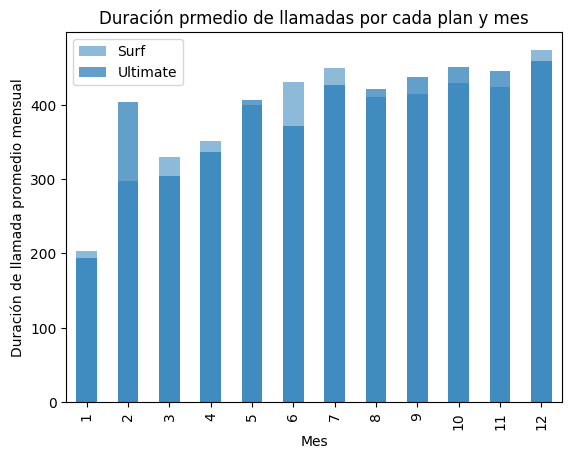

In [41]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
img = consumed.groupby(["plan", "month"])["n_min"].mean()

img.loc["surf"].plot(
    kind = "bar",
    alpha = 0.5,
    label = "Surf"
)

img.loc["ultimate"].plot(
    kind = "bar",
    alpha = 0.7,
    label = "Ultimate"
)

plt.legend()
plt.xlabel("Mes")
plt.ylabel("Duración de llamada promedio mensual")
plt.title("Duración prmedio de llamadas por cada plan y mes")
plt.show()


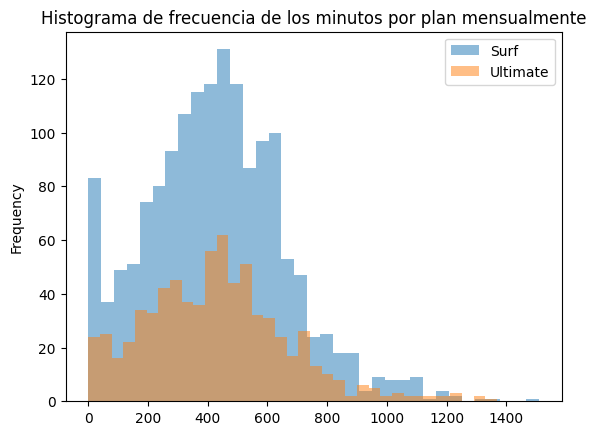

In [42]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
consumed.loc[consumed["plan"] == "surf", "n_min"].plot(
    kind="hist",
    bins=35,
    alpha=0.5,
    label="Surf",
    
)

consumed.loc[consumed["plan"] == "ultimate", "n_min"].plot(
    kind="hist",
    bins=35,
    alpha=0.5,
    label="Ultimate",
    
)

plt.legend()
plt.title("Histograma de frecuencia de los minutos por plan mensualmente")
plt.show()

Calcularé la media, y la varianza de la duración de las llamadas. 

In [43]:
# Calcula la media y la varianza de la duración mensual de llamadas.

#consumed.info()
group = consumed.groupby(["plan", "month"])["n_min"]

mensual_mean = group.mean()
mensual_var = group.var()

print("La media mensual de la duración de las llamadas por plan es de: ", mensual_mean)
print("La varianza mensual de la duración de las llamadas por plan es de: ", mensual_var)

La media mensual de la duración de las llamadas por plan es de:  plan      month
surf      1        203.000000
          2        297.000000
          3        330.000000
          4        351.540000
          5        399.584416
          6        431.298969
          7        449.983471
          8        410.111111
          9        414.226804
          10       429.729958
          11       423.325088
          12       473.836478
ultimate  1        193.500000
          2        403.142857
          3        304.250000
          4        336.857143
          5        406.241379
          6        370.957447
          7        427.067797
          8        421.436620
          9        437.511628
          10       450.735849
          11       445.196850
          12       459.099338
Name: n_min, dtype: float64
La varianza mensual de la duración de las llamadas por plan es de:  plan      month
surf      1        15842.000000
          2        52226.500000
          3        3580

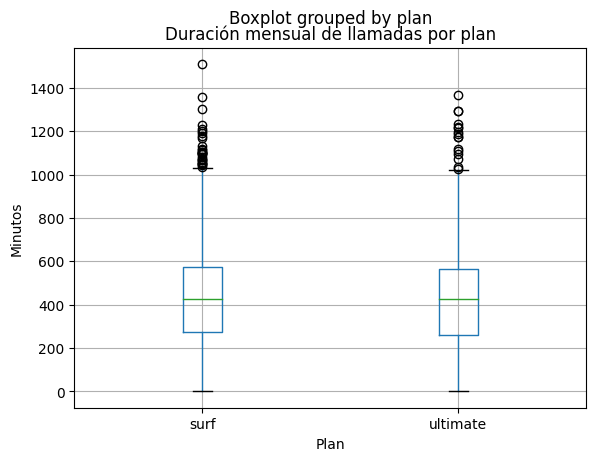

In [44]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
consumed.boxplot(column="n_min", by = "plan")

plt.title("Duración mensual de llamadas por plan")
plt.xlabel("Plan")
plt.ylabel("Minutos")
plt.show()

El cambio varía lo suficiente como para hacer especulaciones a priori, tanto graficamente como por las estadisticas. 

En la grafica de barras, podemos notar como el promedio mensual del plan surf es casi el "doble" que el plan ultimate.

En el grafico de caja, podemos notar que aunque tienen una mediana parecida, la de surf es un poco mayor. Su rango intercuarilico parece simliar (surf un poco arriba). Se puede presenciar una mayor presencia de valores atipicos (mayores) en surf. Lo que nos dice que tiene mayor sesgo positivo. 

Lo que nos lleva a hopotetizar que surf generá más, en las llamadas. 

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Genial. Tus histogramas muestran claramente la diferencia temporal de comportamiento de cada uno de los planes respecto a la duración de las llamadas y la tendencia de minutos usados al mes por plan. Excelente análisis frente a la media y las desviaciones de la duracion de las llamadas por cada plan, como mencionas, esta diferencia no es muy significativa y esto es un dato valioso. 


### Mensajes

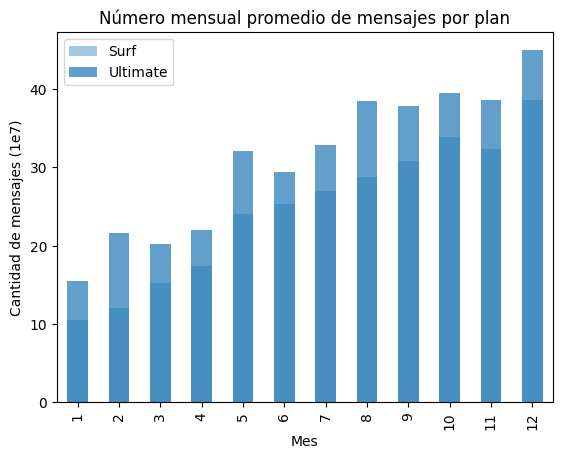

In [45]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
msm_img = consumed.groupby(["plan", "month"])["n_msm"].mean()


msm_img.loc["surf"].plot(
    kind = "bar",
    alpha = 0.4,
    label = "Surf"
)

msm_img.loc["ultimate"].plot(
    kind = "bar",
    alpha = 0.7,
    label = "Ultimate"
)

plt.title("Número mensual promedio de mensajes por plan")
plt.legend()
plt.xlabel("Mes")
plt.ylabel("Cantidad de mensajes (1e7)")
plt.show()

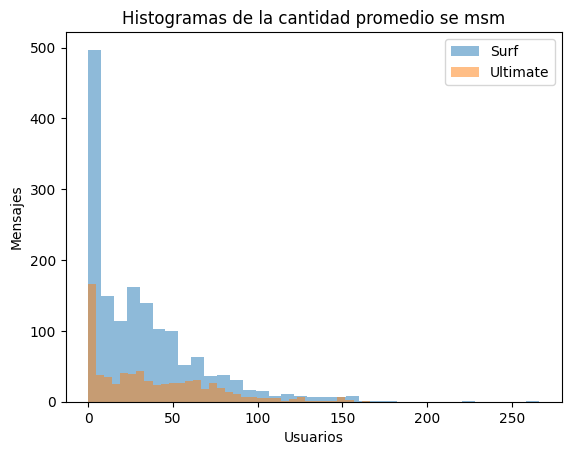

In [46]:
# Compara el número de mensajes mensuales que necesitan los usuarios de cada plan. Traza un histograma.
consumed.loc[consumed["plan"] == "surf", "n_msm"].plot(
    kind = "hist",
    bins = 35,
    alpha = 0.5,
    label = "Surf"
)

consumed.loc[consumed["plan"]=="ultimate", "n_msm"].plot(
    kind = "hist",
    bins = 35,
    alpha = 0.5,
    label = "Ultimate"
)

plt.legend()
plt.title("Histogramas de la cantidad promedio se msm")
plt.xlabel("Usuarios")
plt.ylabel("Mensajes")
plt.show()


In [47]:
#Media y varianza de la canatidad mensual de mensajes
group_msm = consumed.groupby(["plan", "month"])["n_msm"]

mean_msm = group_msm.mean()
var_msm = group_msm.var()

print("El promedio mensual de mensajes es: ", mean_msm)
print("La varianza mensual de mensajes es: ", var_msm)


El promedio mensual de mensajes es:  plan      month
surf      1        10.500000
          2        12.000000
          3        15.260870
          4        17.400000
          5        24.012987
          6        25.298969
          7        27.033058
          8        28.777778
          9        30.762887
          10       33.839662
          11       32.385159
          12       38.600629
ultimate  1        15.500000
          2        21.571429
          3        20.250000
          4        22.047619
          5        32.103448
          6        29.340426
          7        32.830508
          8        38.478873
          9        37.895349
          10       39.443396
          11       38.606299
          12       45.006623
Name: n_msm, dtype: float64
La varianza mensual de mensajes es:  plan      month
surf      1         220.500000
          2         386.000000
          3         346.565217
          4         501.591837
          5         847.197198
          6    

<AxesSubplot:title={'center':'n_msm'}, xlabel='plan'>

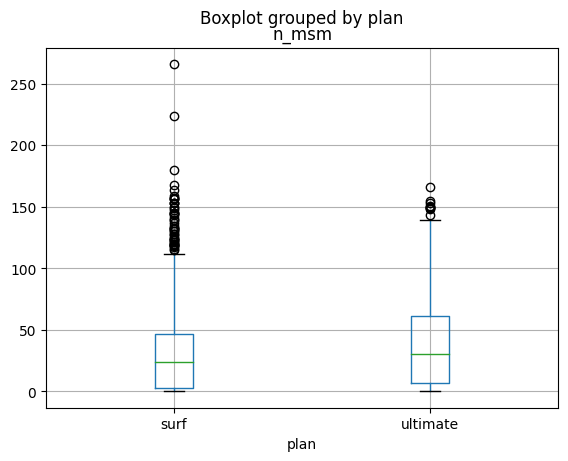

In [48]:
#Diagrama de caja
consumed.boxplot(column = "n_msm", by = "plan")

Ambas distribuciones tienen un sesgo positivo. Tenemos datos atipicos (mas conglomerados en surf).
En promedio los usuarios de ultimate envian más mensajes.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente trabajo aqui con la seccion de Mensajes, todos los graficos y medidas estadisticas solicitadas se encuentran completos. Genial los puntos que señalas sobre las tendencias generales y los valores atípicos en ambos planes. 

### Internet

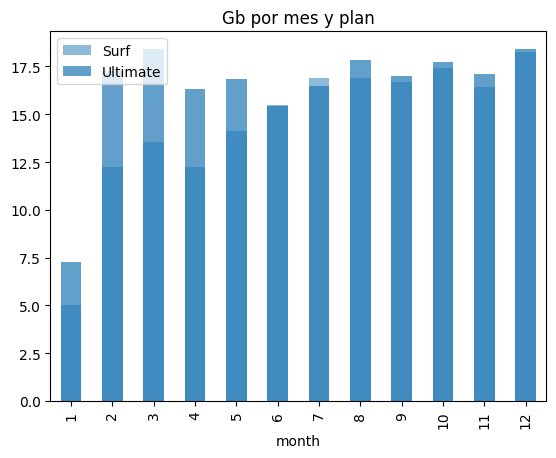

In [49]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan, mensual
group_call = consumed.groupby(["plan", "month"])["n_gb"].mean()

group_call.loc["surf"].plot(
    kind = "bar",
    alpha = 0.5,
    label = "Surf"
)

group_call.loc["ultimate"].plot(
    kind = "bar",
    alpha = 0.7,
    label = "Ultimate"
)


plt.title("Gb por mes y plan")
plt.legend()

plt.show()


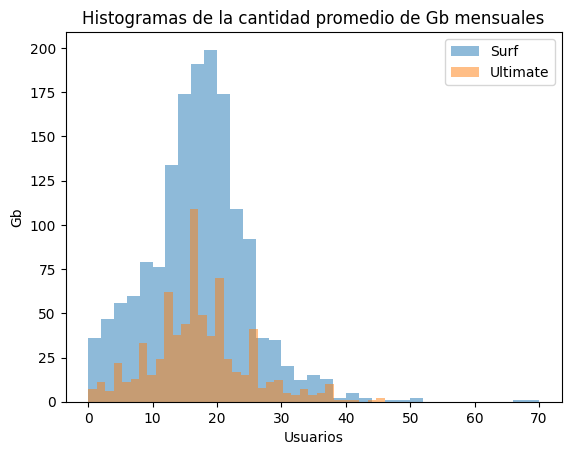

In [50]:
#Histograma
consumed.loc[consumed["plan"] == "surf", "n_gb"].plot(
    kind = "hist",
    bins = 35,
    alpha = 0.5,
    label = "Surf"
)

consumed.loc[consumed["plan"] == "ultimate", "n_gb"].plot(
    kind = "hist",
    bins = 35,
    alpha = 0.5,
    label = "Ultimate"
)

plt.legend()
plt.title("Histogramas de la cantidad promedio de Gb mensuales")
plt.xlabel("Usuarios")
plt.ylabel("Gb")
plt.show()


In [51]:
#Media y varianza de la canatidad mensual de mensajes
group_gb = consumed.groupby(["plan", "month"])["n_gb"]

mean_gb = group_gb.mean()
var_gb = group_gb.var()

print("El promedio mensual de mensajes es: ", mean_gb)
print("La varianza mensual de mensajes es: ", var_gb)


El promedio mensual de mensajes es:  plan      month
surf      1         5.000000
          2        12.222222
          3        13.565217
          4        12.220000
          5        14.116883
          6        15.484536
          7        16.876033
          8        16.882716
          9        16.690722
          10       17.409283
          11       16.431095
          12       18.238994
ultimate  1         7.250000
          2        17.285714
          3        18.416667
          4        16.333333
          5        16.862069
          6        15.425532
          7        16.491525
          8        17.845070
          9        17.011628
          10       17.716981
          11       17.118110
          12       18.397351
Name: n_gb, dtype: float64
La varianza mensual de mensajes es:  plan      month
surf      1         18.000000
          2         41.444444
          3         63.984190
          4         56.215918
          5         58.183527
          6         4

<AxesSubplot:title={'center':'n_gb'}, xlabel='plan'>

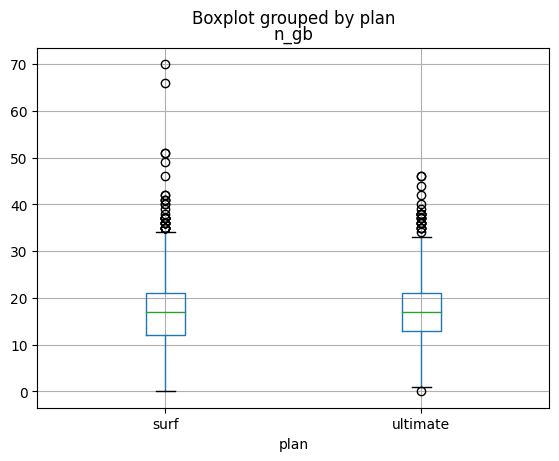

In [52]:
#Boxplot
consumed.boxplot(column = "n_gb", by = "plan")

Aqui es evidente que ultimate esta un poco a la derecha de surf (la distribución). 
Pero en esta situación surf tiene una cola mas larga.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente análisis frente al consumo de internet por plan. De nuevo como remarcas, el comportamiento entre ambos planes es similar, siendo uno de los mayores diferenciadores el consumo de excedentes por parte de los usuarios del plan surf. 


## Ingreso

Ahora, en este analisis agregaremos sel dato de los costos para llegar a la conclusión deseada.

La media de los ingresos mensual por plan es: plan      month
surf      1        20.000000
          2        34.396667
          3        45.941304
          4        40.710600
          5        47.628182
          6        49.276289
          7        62.674050
          8        63.931173
          9        58.271495
          10       65.421224
          11       58.004276
          12       70.557044
ultimate  1        70.000000
          2        70.000000
          3        74.666667
          4        73.000000
          5        70.724138
          6        71.638298
          7        71.898305
          8        72.859155
          9        72.034884
          10       72.311321
          11       71.708661
          12       73.291391
Name: Total, dtype: float64
La mediana de los ingresos mensual por plan es: plan      month
surf      1        20.000
          2        29.570
          3        20.000
          4        20.000
          5        21.740
          6        3

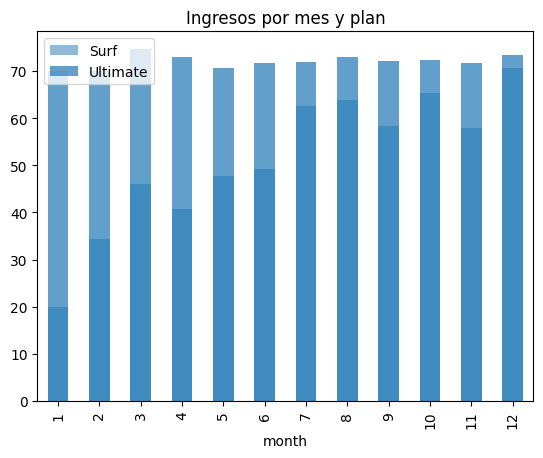

In [53]:
# Compara la cantidad de ingresos por usuarios por plan, mensual
group_income = consumed.groupby(["plan", "month"])["Total"].mean()
group_incomes = consumed.groupby(["plan", "month"])["Total"]

print(f"La media de los ingresos mensual por plan es: {group_income}")
print(f"La mediana de los ingresos mensual por plan es: {group_incomes.median()}")
print(f"La varianza de los ingresos mensual por plan es: {group_incomes.var()}")


group_income.loc["surf"].plot(
    kind = "bar",
    alpha = 0.5,
    label = "Surf"
)

group_income.loc["ultimate"].plot(
    kind = "bar",
    alpha = 0.7,
    label = "Ultimate"
)


plt.title("Ingresos por mes y plan")
plt.legend()

plt.show()


In [54]:
print(consumed[consumed["plan"] == "ultimate"].head())

    user_id  month  n_calls  n_min  n_msm  n_gb      plan  messages_included  \
0      1000     12     16.0  124.0   11.0   2.0  ultimate               1000   
19     1006     11      2.0   10.0   15.0   3.0  ultimate               1000   
20     1006     12      9.0   59.0  139.0  32.0  ultimate               1000   
26     1008     10     71.0  476.0   21.0  17.0  ultimate               1000   
27     1008     11     63.0  446.0   37.0  24.0  ultimate               1000   

    mb_per_month_included  minutes_included  ...  usd_per_gb  usd_per_message  \
0                   30720              3000  ...           7             0.01   
19                  30720              3000  ...           7             0.01   
20                  30720              3000  ...           7             0.01   
26                  30720              3000  ...           7             0.01   
27                  30720              3000  ...           7             0.01   

    usd_per_minute  gb_per_month

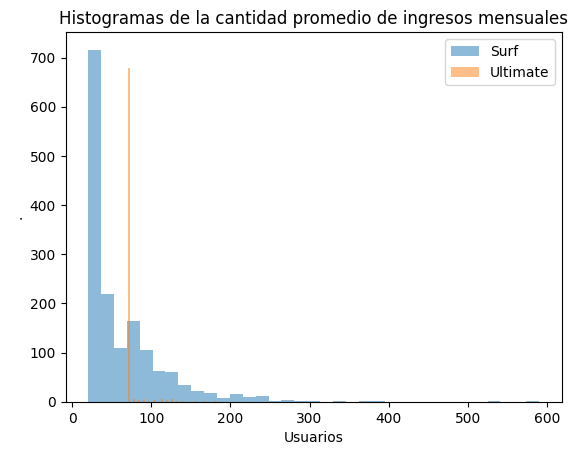

In [55]:
#Histograma
consumed.loc[consumed["plan"] == "surf", "Total"].plot(
    kind = "hist",
    bins = 35,
    alpha = 0.5,
    label = "Surf"
)

consumed.loc[consumed["plan"] == "ultimate", "Total"].plot(
    kind = "hist",
    bins = 35,
    alpha = 0.5,
    label = "Ultimate"
)

plt.legend()
plt.title("Histogramas de la cantidad promedio de ingresos mensuales")
plt.xlabel("Usuarios")
plt.ylabel(".")
plt.show()

<AxesSubplot:title={'center':'Total'}, xlabel='plan'>

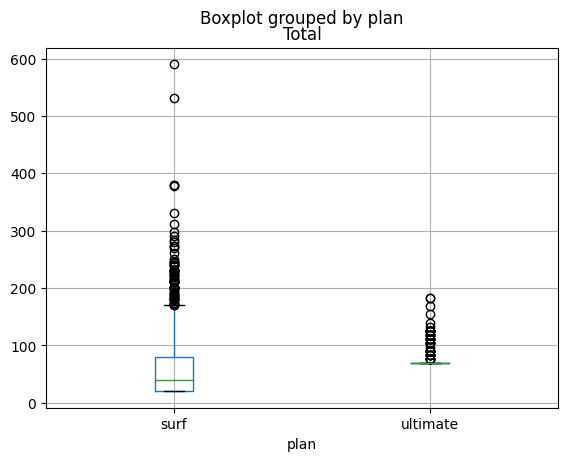

In [56]:
#Boxplot
consumed.boxplot(column = "Total", by = "plan")

Mensualmente la mediana y media son mahores en ultimate. 

Pero la varianza de surf le gana significativamente a ultimate. 

Y parece  que tenemos muchos mas datos en surf.

Podemos ver que la distribución de surf tiene un sesgo positvo. Al igual que ultimate. Pero como surf tiene mas varianza, lo cual es evidente en la grafica de histograma y en el boxplot.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo señalando cómo la varianza del plan surf es mucho más amplia que la del plan ultimate. esto es relevante además de los outliers, que muestrna cómo los usuarios tienen altos consumos en excedentes.

La hipotesis nula es que los promedios son iguales. 

Y la hipotesis alternativa es que difieren (uno es mayor que otro)

El nivel de significancia será de 0.05.

In [60]:
# Prueba las hipótesis

results = st.ttest_ind(consumed.loc[consumed["plan"] == "surf","Total"],
                       consumed.loc[consumed["plan"] == "ultimate","Total"],
                       equal_var = False)
print(results.pvalue)
print(f"p-value: {results.pvalue:.5f}")
alpha = 0.05

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula.")
    print("Existe evidencia suficiente para afirmar que el ingreso promedio de los usuarios de los planes Surf y Ultimate es diferente.")
else:
    print("No rechazamos la hipótesis nula.")
    print("No existe evidencia suficiente para afirmar que el ingreso promedio de los usuarios de los planes Surf y Ultimate sea diferente.")

3.1703905481135734e-15
p-value: 0.00000
Rechazamos la hipótesis nula.
Existe evidencia suficiente para afirmar que el ingreso promedio de los usuarios de los planes Surf y Ultimate es diferente.


Ahora probaremos si el promedio de los ingresos de los usarios del area NY-NJ es diferente al ddel resto de regiones.

La hipotesis nula es que los promedios son iguales. 

Y la hipotesis alternativa es que difieren (uno es mayor que otro)

El nivel de significancia será de 0.05.

In [61]:
# Prueba las hipótesis

# Agregar la ciudad al DataFrame de consumo
consumed_region = consumed.merge(
    users[["user_id", "city"]],
    on="user_id",
    how="left"
)

# Crear las dos muestras
ny_nj = consumed_region.loc[
    consumed_region["city"] == "New York-Newark-Jersey City, NY-NJ-PA MSA",
    "Total"
]

others = consumed_region.loc[
    consumed_region["city"] != "New York-Newark-Jersey City, NY-NJ-PA MSA",
    "Total"
]

# Nivel de significancia
alpha = 0.05

# Prueba t de Welch
results = st.ttest_ind(
    ny_nj,
    others,
    equal_var=False
)


print(f"p-value: {results.pvalue:.5f}")

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula.")
    print("Existe evidencia de que el ingreso promedio de los usuarios de NY-NJ es diferente al de otras regiones.")
else:
    print("No rechazamos la hipótesis nula.")
    print("No existe evidencia suficiente para afirmar que los ingresos promedio sean diferentes.")



p-value: 0.03353
Rechazamos la hipótesis nula.
Existe evidencia de que el ingreso promedio de los usuarios de NY-NJ es diferente al de otras regiones.


In [111]:
users.loc[
    users["city"].str.contains("New York", na=False),
    "city"
].unique()

array(['New York-Newark-Jersey City, NY-NJ-PA MSA'], dtype=object)

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente uso de `ttest_ind` de scipy para tus pruebas de hipotesis. Has conseguido llegar a la conclusion esperada y demostrar con claridad la diferencia entre los planes de telefonia. 

## Conclusión general


Cambiamos los formatos y limpiamos las bases. Y las "acomodamos" en la forma en que nos fuera útil. Uniendo columnas cuando lo creimos conveniente. Cambiamos el tipo de columna, e hicimos conversiones (como de mb a gb), y rellenamos datos ausentes.

Buscamos el numero de llamadas, mensaje, volumen de datos por mes. Y calculamos el ingreso que todo eso nos generaba, por usuario.

Nos dimos cuenta que el promedio de ingresos es mayor en ultimate. Pero por la cantidad de usuarios en self. Es el subgrupo que nos genera mayor ganancia.

También rechazamos la hipotesis de que las medias son iguales. Existe evidencia suficiente para declarar que el promedio de los ingresos de surf y ultimate cambia significativamente, asi como los usuarios de las regiones de New York - New Jersy con el resto de regines.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelentes conclusiones finales. Describiste detalladamente los resultados segun las categorias de llamadas, mensajes e internet para cada tipo de plan y sus hallazgos relevantes. 